# Name:Syeda Reja Fatima
# Roll no: 24F-AI-024
# Project Name:Employee Attrition Analyzer



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [19]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

In [5]:
# Remove unnecessary columns
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)
# Convert categorical columns into numbers


In [24]:
#4. Convert Attrition into Numbers
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [22]:
# 5. Convert Categorical Columns into Numbers
df = pd.get_dummies(df, drop_first=True)

In [23]:
# 6. Separate Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [27]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Preprocessing completed!")

Preprocessing completed!


In [30]:
# 9. Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_prediction = logistic_model.predict(X_test)

In [32]:
# Model 2: Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5,random_state=42)
tree_model.fit(X_train, y_train)
tree_prediction = tree_model.predict(X_test)

In [33]:
#Model 3: Random forest
forest_model = RandomForestClassifier(n_estimators=100,random_state=42)
forest_model.fit(X_train, y_train)
forest_prediction = forest_model.predict(X_test)


In [34]:
# 12. Evaluate Logistic Regression
logistic_accuracy = accuracy_score( y_test,logistic_prediction)
logistic_f1 = f1_score( y_test,logistic_prediction)
print(" Regression")
print("Accuracy:", logistic_accuracy)
print("F1 Score:", logistic_f1)

 Regression
Accuracy: 0.8605442176870748
F1 Score: 0.4383561643835616


In [35]:
# 13. Evaluate Decision Tree
tree_accuracy = accuracy_score(y_test,tree_prediction)
tree_f1 = f1_score(y_test,tree_prediction)
print(" Decision Tree")
print("Accuracy:", tree_accuracy)
print("F1 Score:", tree_f1)

 Decision Tree
Accuracy: 0.8333333333333334
F1 Score: 0.26865671641791045


In [36]:
# 14. Evaluate Random Forest
forest_accuracy = accuracy_score(y_test,forest_prediction)
forest_f1 = f1_score( y_test,forest_prediction)
print("Random Forest")
print("Accuracy:", forest_accuracy)
print("F1 Score:", forest_f1)

Random Forest
Accuracy: 0.8299319727891157
F1 Score: 0.13793103448275862


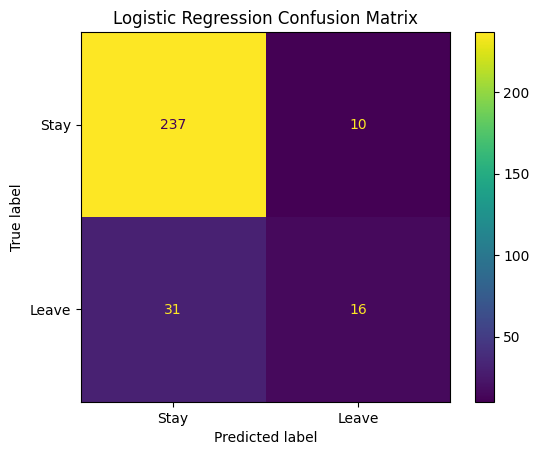

In [37]:
# 15. Confusion Matrix - Logistic Regression
cm_logistic = confusion_matrix(y_test,logistic_prediction)
display = ConfusionMatrixDisplay( confusion_matrix=cm_logistic,display_labels=["Stay", "Leave"])
display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


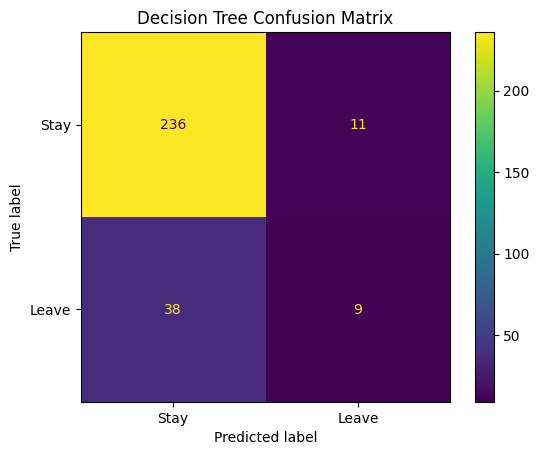

In [38]:
# 16. Confusion Matrix - Decision Tree
cm_tree = confusion_matrix( y_test,tree_prediction)
display = ConfusionMatrixDisplay(confusion_matrix=cm_tree,display_labels=["Stay", "Leave"])
display.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

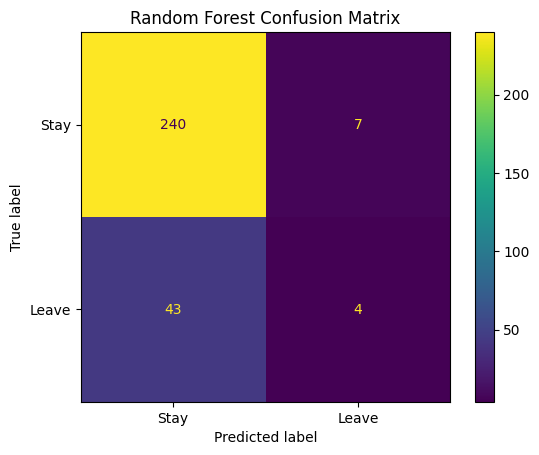

In [40]:
# 17. Confusion Matrix - Random Forest
cm_forest = confusion_matrix(y_test,forest_prediction)
display = ConfusionMatrixDisplay(confusion_matrix=cm_forest,display_labels=["Stay", "Leave"])
display.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [41]:
# 18. Random Forest Feature Importance
importance = pd.Series(forest_model.feature_importances_,index=X.columns)
importance = importance.sort_values(
    ascending=False
).head(10)
print("\nTop 10 Important Features:")
print(importance)


Top 10 Important Features:
MonthlyIncome        0.066978
TotalWorkingYears    0.065706
Age                  0.059688
DailyRate            0.049455
MonthlyRate          0.046730
HourlyRate           0.044815
EmployeeNumber       0.044738
DistanceFromHome     0.042155
OverTime_Yes         0.037496
YearsAtCompany       0.037261
dtype: float64


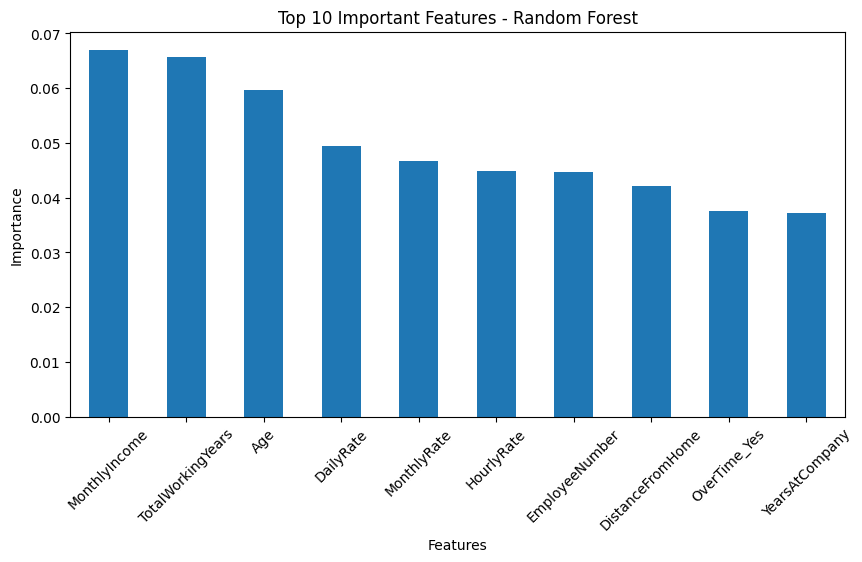

In [42]:
# 19. Feature Importance Visualization
importance.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [44]:
#20. Model Comparison
print(" Model Comparison ")
print("\nLogistic Regression")
print("Accuracy:", logistic_accuracy)
print("F1 Score:", logistic_f1)
print("\nDecision Tree")
print("Accuracy:", tree_accuracy)
print("F1 Score:", tree_f1)
print("\nRandom Forest")
print("Accuracy:", forest_accuracy)
print("F1 Score:", forest_f1)

 Model Comparison 

Logistic Regression
Accuracy: 0.8605442176870748
F1 Score: 0.4383561643835616

Decision Tree
Accuracy: 0.8333333333333334
F1 Score: 0.26865671641791045

Random Forest
Accuracy: 0.8299319727891157
F1 Score: 0.13793103448275862
